In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
params = {'figure.figsize': (7, 7*0.618),
          'legend.fontsize': 14,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)

In [3]:
bins_prob = np.arange(0, 1, 0.02)

In [4]:
bins_prob

array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
       0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
       0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
       0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
       0.88, 0.9 , 0.92, 0.94, 0.96, 0.98])

In [5]:
bins_prob[:-1] + 0.02*0.5

array([0.01, 0.03, 0.05, 0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19, 0.21,
       0.23, 0.25, 0.27, 0.29, 0.31, 0.33, 0.35, 0.37, 0.39, 0.41, 0.43,
       0.45, 0.47, 0.49, 0.51, 0.53, 0.55, 0.57, 0.59, 0.61, 0.63, 0.65,
       0.67, 0.69, 0.71, 0.73, 0.75, 0.77, 0.79, 0.81, 0.83, 0.85, 0.87,
       0.89, 0.91, 0.93, 0.95, 0.97])

In [6]:
df = pd.read_hdf('/data/user/akatil/electron_neutrino/for_real/dataset_complete/BDT/BDT_all_updated_with_muon.h5', key='data')

HistGradientBoostingClassifier(learning_rate=0.275, 
                               max_iter=1000, 
                               early_stopping=True, 
                               validation_fraction=0.2, 
                               n_iter_no_change=10, 
                               random_state=0)

GradientBoostingClassifier(learning_rate=0.275,
                           n_estimators=80,
                           max_depth=5,
                           min_samples_split=1100,
                           min_samples_leaf=5,
                           max_features=11,
                           validation_fraction=0.2, 
                           n_iter_no_change=10, 
                           random_state=0)

In [7]:
features = ['RecoEnergy',
 'TotalCharge',
 'CogDistance',
 'Beta1Reco',
 'tres_median',
 'tres_iqr',
 'tres_skew',
 'dist_iqr',
 'dist_skew',
 'ang_median',
 'ang_iqr',
 'ang_kurtosis',
 'ang_skew']
correlation_cc = df[features][df['Label'] == 1].corr()#[(df['TrueEnergy']>=2)&(df['TrueEnergy']<=15)&(df['TrueZenith']<=-0.3)].corr()
correlation_nc = df[features][df['Label'] == 0].corr()#[(df['TrueEnergy']>=2)&(df['TrueEnergy']<=15)&(df['TrueZenith']<=-0.3)].corr()
correlation_muon = df[features][df['Label'] == 2].corr()

In [8]:
np.sum(np.bincount(df['Label']))/(2*np.bincount(df['Label']))

array([1.39193411, 4.2967237 , 0.95343452])

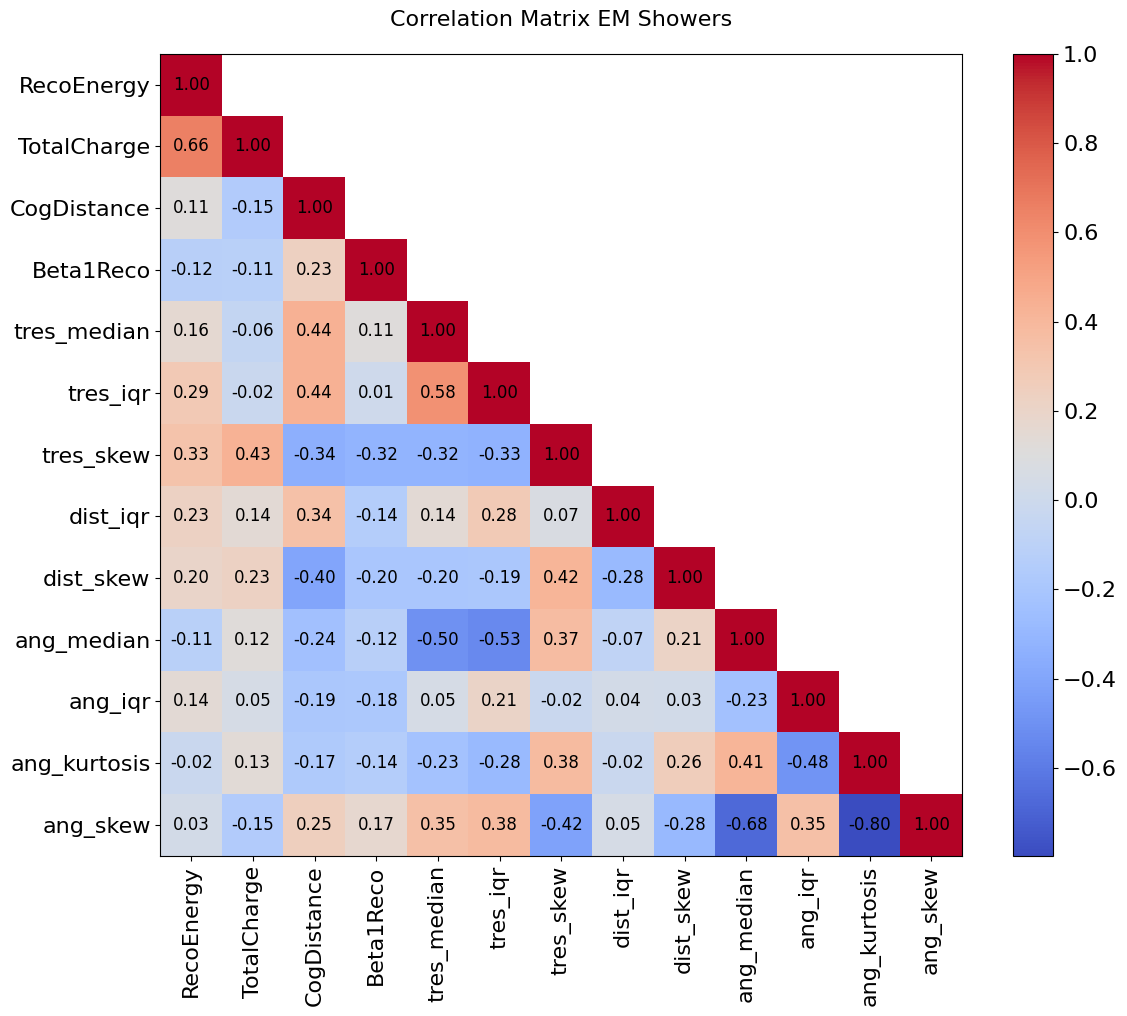

In [12]:
mask = np.tril(np.ones_like(correlation_cc, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(correlation_cc.where(mask), cmap='coolwarm')

# Add colorbar
fig.colorbar(cax)

# Add ticks and labels
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=90)
ax.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
ax.set_yticklabels(features)

# Plot correlation values in each cell
for i in range(len(features)):
    for j in range(len(features)):
        if mask[i, j]:
            value = correlation_cc.iloc[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=12)


plt.title("Correlation Matrix EM Showers", pad=20)
plt.tight_layout()
#plt.show()
plt.savefig('./Correlation_Matrix_EM_Showers.pdf', bbox_inches='tight', dpi=200)

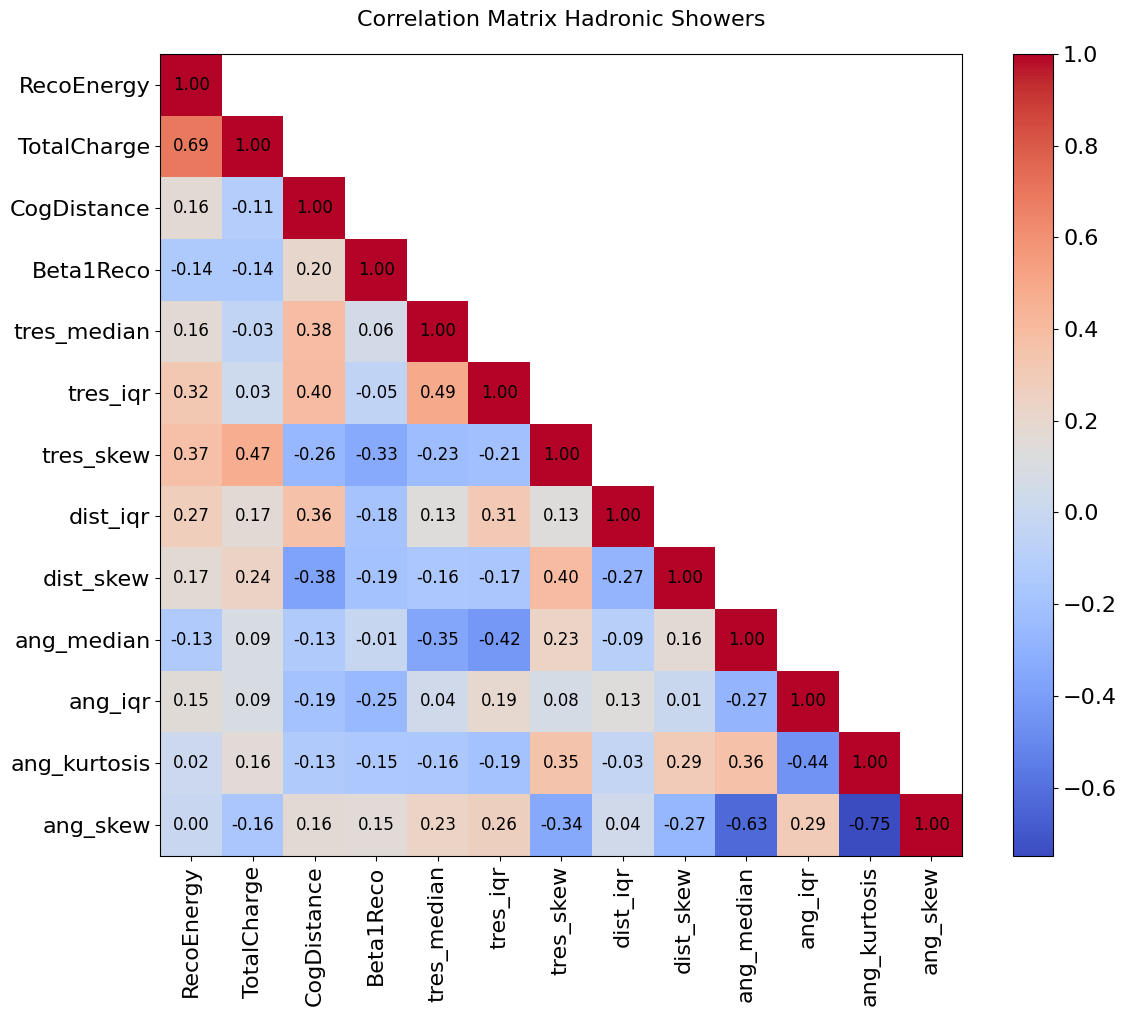

In [13]:
mask = np.tril(np.ones_like(correlation_nc, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(correlation_nc.where(mask), cmap='coolwarm')

# Add colorbar
fig.colorbar(cax)

# Add ticks and labels
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=90)
ax.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
ax.set_yticklabels(features)

# Plot correlation values in each cell
for i in range(len(features)):
    for j in range(len(features)):
        if mask[i, j]:
            value = correlation_nc.iloc[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=12)


plt.title("Correlation Matrix Hadronic Showers", pad=20)
plt.tight_layout()
#plt.show()
plt.savefig('./Correlation_Matrix_Hadronic_Showers.pdf', bbox_inches='tight', dpi=200)

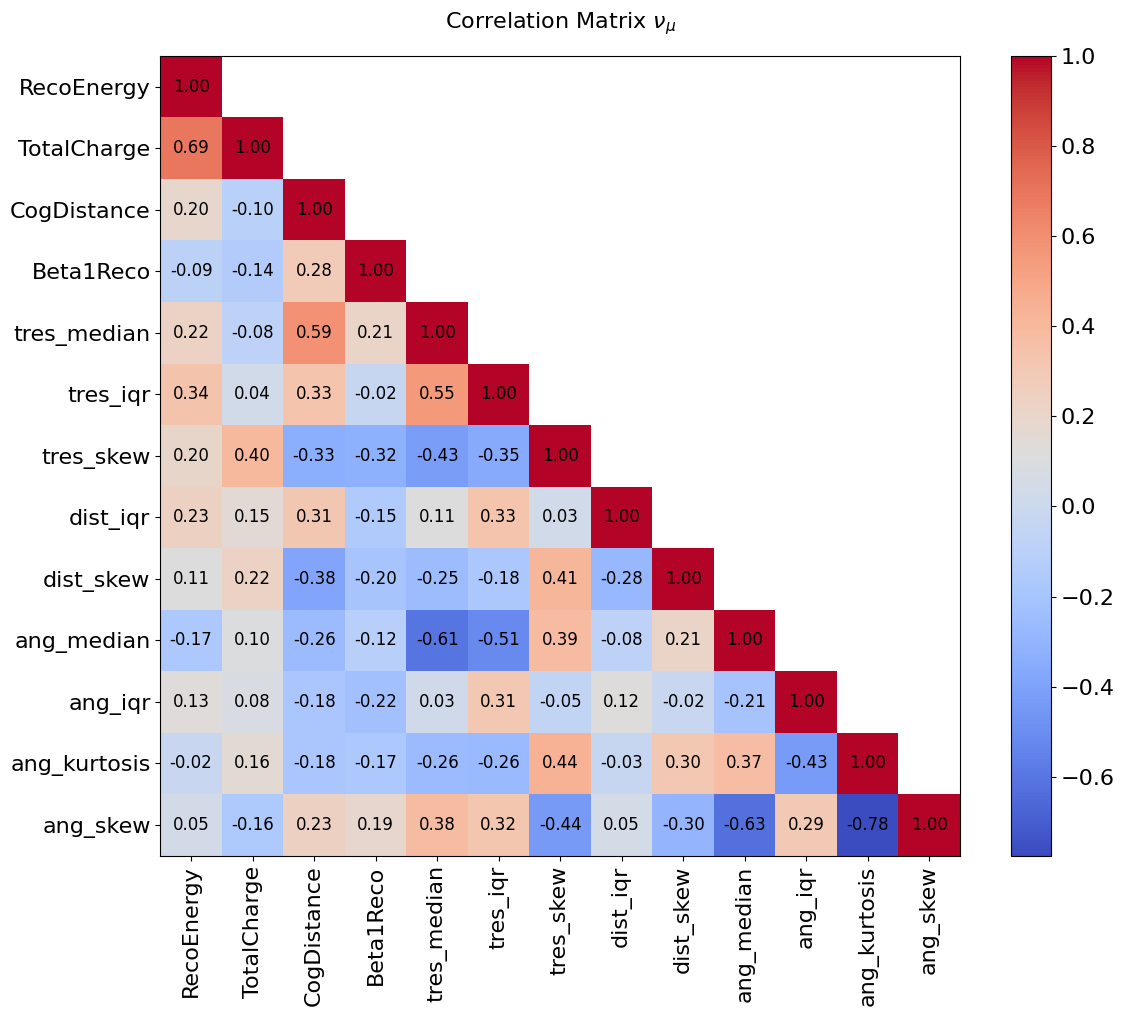

In [14]:
mask = np.tril(np.ones_like(correlation_muon, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(correlation_muon.where(mask), cmap='coolwarm')

# Add colorbar
fig.colorbar(cax)

# Add ticks and labels
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=90)
ax.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
ax.set_yticklabels(features)

# Plot correlation values in each cell
for i in range(len(features)):
    for j in range(len(features)):
        if mask[i, j]:
            value = correlation_muon.iloc[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=12)


plt.title(r'Correlation Matrix $\nu_\mu$', pad=20)
plt.tight_layout()
#plt.show()
plt.savefig('./Correlation_Matrix_NuMu.pdf', bbox_inches='tight', dpi=200)

NameError: name 'correlation' is not defined

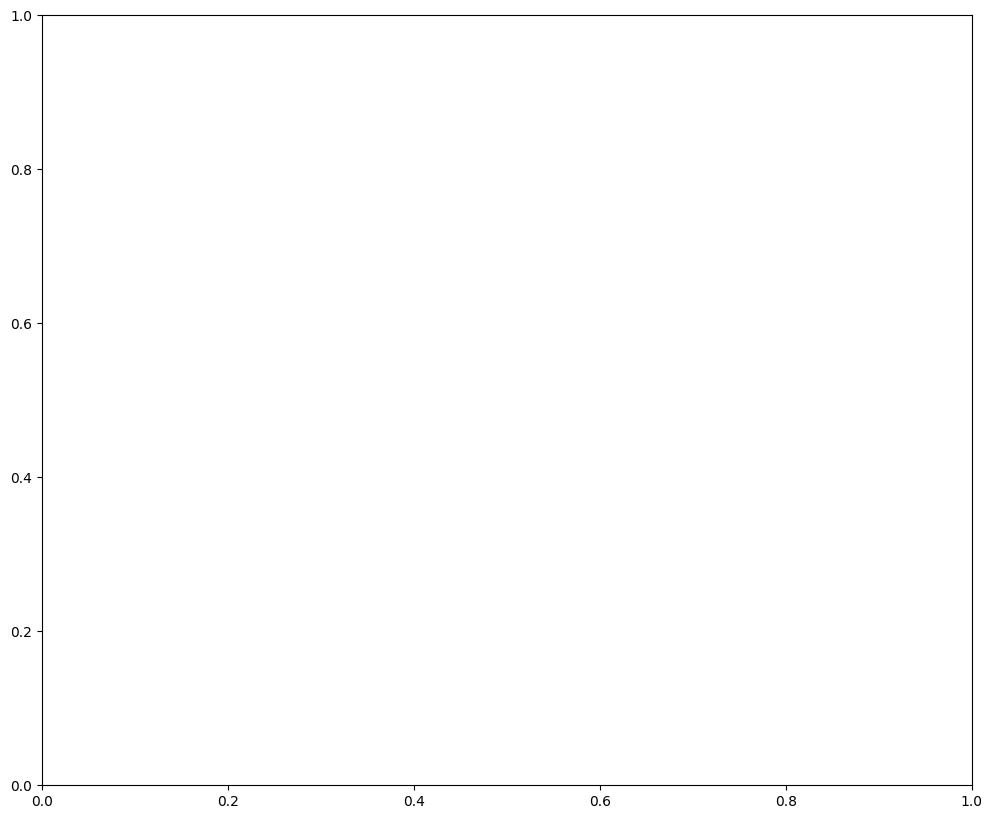

In [12]:
fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(correlation[correlation >= 0.7], cmap='coolwarm')
# Add colorbar
fig.colorbar(cax)

# Add ticks and labels
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=90)
ax.set_yticklabels(features)

plt.title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()

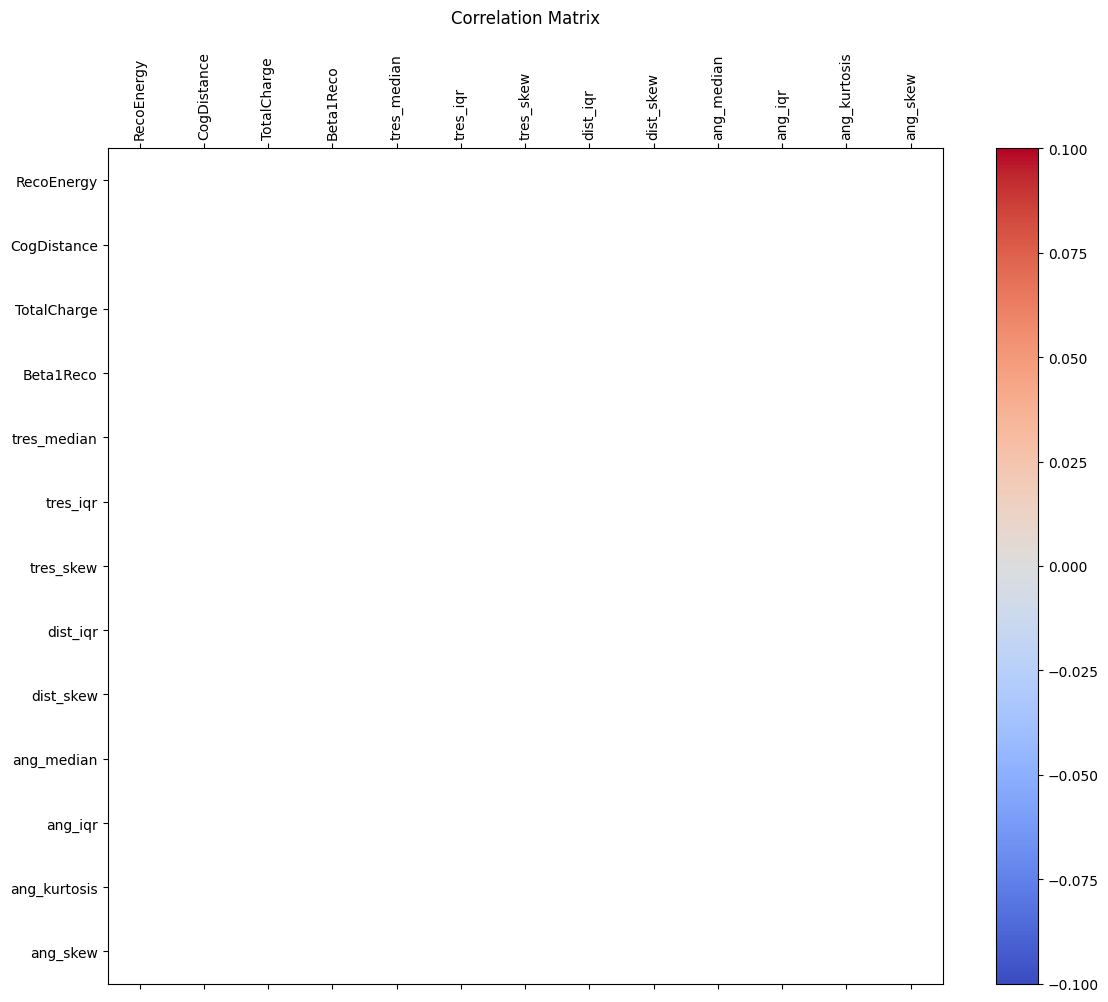

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.matshow(correlation[correlation <= -0.8], cmap='coolwarm')

# Add colorbar
fig.colorbar(cax)

# Add ticks and labels
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=90)
ax.set_yticklabels(features)

plt.title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()

In [11]:
df['RecoEnergy'][df['RecoEnergy']<=15][df['Label']==0]

0           3.734664
1           9.475776
2          11.598042
4           3.504687
6           2.677844
             ...    
1867982     4.229039
1867983    10.162115
1867984     8.628593
1867985    10.726761
1867986     5.684070
Name: RecoEnergy, Length: 1194206, dtype: float64

In [9]:
df['RecoEnergy'][df['Label']==1]

3          33.671581
5           5.652726
7           3.706903
9           5.086470
12          2.457051
             ...    
1867954    14.044749
1867959    11.871307
1867969    22.731724
1867976     5.151770
1867980    31.019222
Name: RecoEnergy, Length: 457070, dtype: float64

In [10]:
df['RecoEnergy'][df['Label']==0]

0           3.734664
1           9.475776
2          11.598042
4           3.504687
6           2.677844
             ...    
1867982     4.229039
1867983    10.162115
1867984     8.628593
1867985    10.726761
1867986     5.684070
Name: RecoEnergy, Length: 1410917, dtype: float64

In [11]:
df['RecoEnergy'][df['RecoEnergy']<20][df['Label']==1]

5           5.652726
7           3.706903
9           5.086470
12          2.457051
15         12.774947
             ...    
1867951     2.441824
1867953     2.900004
1867954    14.044749
1867959    11.871307
1867976     5.151770
Name: RecoEnergy, Length: 367454, dtype: float64

In [12]:
label = [0, 1]
vals = [df['RecoEnergy'][df['Label'] == 0], df['RecoEnergy'][df['Label'] == 1]]

(array([4.06743e+05, 3.52420e+04, 9.08000e+03, 4.09800e+03, 1.61800e+03,
        2.67000e+02, 2.00000e+01, 1.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([  1.36854005,  28.87892725,  56.38931446,  83.89970167,
        111.41008887, 138.92047608, 166.43086329, 193.94125049,
        221.4516377 , 248.9620249 , 276.47241211]),
 <BarContainer object of 10 artists>)

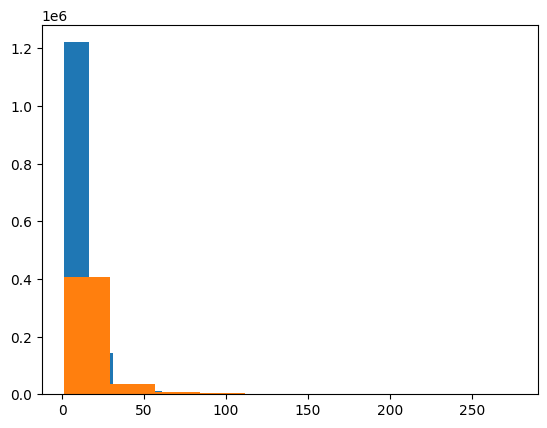

In [14]:
plt.hist(df['RecoEnergy'][df['Label'] == 0])
plt.hist(df['RecoEnergy'][df['Label'] == 1])

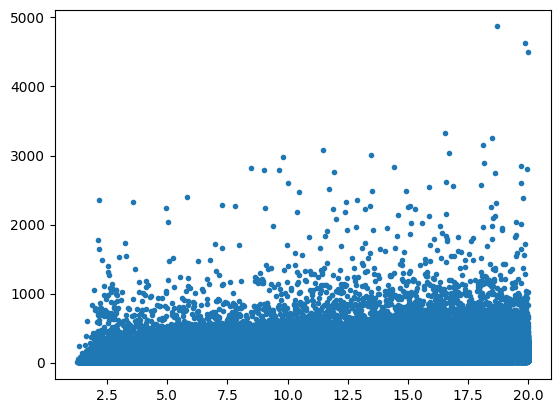

In [18]:
plt.plot(df['RecoEnergy'][df['RecoEnergy']<=20], df['TotalCharge'][df['RecoEnergy']<=20], '.')

In [8]:
np.linspace(np.log10(3), np.log10(300), 12)

array([0.47712125, 0.65893944, 0.84075762, 1.0225758 , 1.20439398,
       1.38621216, 1.56803035, 1.74984853, 1.93166671, 2.11348489,
       2.29530307, 2.47712125])

In [23]:
np.bincount(df['Label'][(df['TrueEnergy']<=20)])

array([1236650,  394019])

In [20]:
np.bincount(df['Label'][(df['TrueEnergy']>=2)&(df['TrueEnergy']<=15)])

array([712822, 266473])

In [21]:
np.bincount(df['Label'][(df['TrueEnergy']>=2)&(df['TrueEnergy']<=15)&(df['TrueZenith']<=-0.3)])

array([252879,  95380])

In [12]:
np.bincount(df['Label'][(df['RecoEnergy']>=2)&(df['RecoEnergy']<=15)])

array([1169726,  326259])

In [18]:
np.bincount(df['Label'][(df['RecoEnergy']>=2)&(df['RecoEnergy']<=15)&(df['RecoZenith']<=-0.3)])

array([430778, 122198])

In [19]:
np.bincount(df['Label'])

array([1410917,  457070])

# Testing Labels

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df = pd.read_hdf('/data/user/akatil/electron_neutrino/for_real/dataset_complete/BDT/BDT_all_updated.h5', key='data')

In [9]:
df.Label

0          0.0
1          0.0
2          0.0
3          1.0
4          0.0
          ... 
1867982    0.0
1867983    0.0
1867984    0.0
1867985    0.0
1867986    0.0
Name: Label, Length: 1867987, dtype: float64

In [10]:
df.dropna(inplace=True)
data = df[df['TrueEnergy'] <= 15] #[(df['TrueEnergy']>=2)&(df['TrueEnergy']<=15)&(df['TrueZenith']<=-0.3)] #[df['RecoEnergy'] < 20] #.sample(420000, random_state=42)
data = data.groupby('Label').sample(200000, random_state=0) #data.groupby('Label').sample(200000, random_state=0)

y = data.Label

In [12]:
df[(df['TrueEnergy']>=2)&(df['TrueEnergy']<=15)&(df['TrueZenith']<=-0.3)&(df.Label == 0)]

,Label,EventCounter,RecoEnergy,CogDistance,TotalmDOMCharge,TotalCharge,Beta1Reco,Beta2Reco,Beta3Reco,Beta4Reco,...,ang_mean,ang_std,ang_median,ang_iqr,ang_sum,ang_kurtosis,ang_skew,TrueZenith,TrueEnergy,RecoZenith
0,0.0,2.000034e+10,3.734664,20.381536,1.767075,9.634213,-0.152704,-0.120796,-0.226170,1.115879e-01,...,0.269216,0.598510,0.665653,0.647649,0.807647,-1.500000,-0.702951,-0.704753,4.183624,0.624839
2,0.0,2.000017e+10,11.598042,29.529109,39.816124,58.989796,0.001217,0.000045,0.000116,1.632258e-04,...,-0.292059,0.394224,-0.187163,0.510396,-10.514125,-0.998126,-0.492746,-0.469433,6.707452,0.288062
6,0.0,2.000105e+10,2.677844,9.429592,10.665665,16.938196,0.023587,0.012012,0.006860,4.802714e-03,...,0.621454,0.433509,0.621091,0.328470,6.214536,3.190536,-1.995365,-0.441492,2.717197,0.812567
17,0.0,2.000021e+10,7.773974,32.688600,20.832524,50.688234,0.003231,0.000062,-0.000143,-3.619797e-07,...,0.594977,0.297728,0.698973,0.361173,13.684473,-0.184131,-0.915893,-0.686813,2.627596,-0.405594
18,0.0,2.000059e+10,11.854248,53.218411,13.593858,29.672480,0.015837,0.007161,0.000919,-1.047305e-03,...,0.034137,0.372948,-0.014025,0.651196,0.477913,-1.375081,-0.015170,-0.349728,2.975553,0.392401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1867952,0.0,2.000110e+10,6.354589,42.418367,9.917306,17.846156,0.025100,0.009551,0.006737,6.790177e-03,...,0.708353,0.128596,0.673635,0.203240,7.083531,-1.177723,0.090005,-0.549991,11.545487,-0.308971
1867957,0.0,2.000119e+10,2.677233,28.931454,7.116382,15.286388,0.015155,0.013875,0.019581,7.049540e-03,...,0.455100,0.342710,0.380051,0.401884,3.640800,-0.708988,-0.106405,-0.590236,2.303937,-0.763700
1867979,0.0,2.000139e+10,15.916985,24.933033,73.843510,131.281550,0.000118,0.000069,0.000019,2.075006e-05,...,0.366833,0.354281,0.364405,0.449426,29.346617,0.527822,-0.450717,-0.372308,8.693073,-0.132165
1867982,0.0,2.000012e+10,4.229039,12.678724,21.113550,42.839713,0.002861,0.001292,0.001061,8.747003e-04,...,0.507125,0.479520,0.722645,0.799593,11.156757,-0.771105,-0.787164,-0.611742,10.125713,-0.513998


In [2]:
df = pd.read_hdf('/data/user/akatil/electron_neutrino/for_real/dataset_complete/BDT/BDT_all_numu_nue.h5', key='data')
df.dropna(inplace=True)

In [3]:
data = df[(df['TrueEnergy']>=2)&(df['TrueEnergy']<=15)&(df['TrueZenith']<=-0.3)] #[df['RecoEnergy'] < 20] #.sample(420000, random_state=42)
data = data.groupby('Label').sample(94592, random_state=0) #data.groupby('Label').sample(200000, random_state=0)

In [4]:
import matplotlib.pyplot as plt

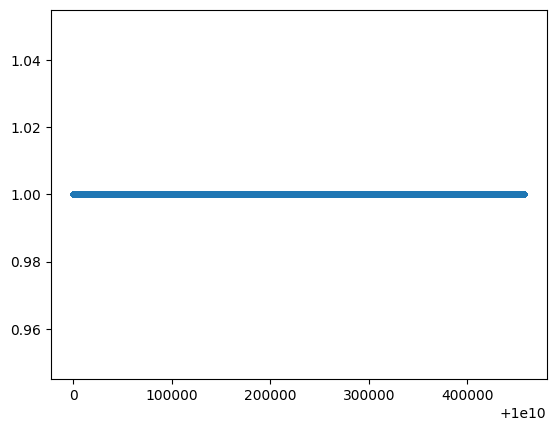

In [5]:
plt.plot(data.EventCounter[df.Label == 1.0], data.Label[df.Label == 1.0], '.')

In [14]:
data.EventCounter[data.Label == 1.0]

2108198    1.000007e+10
830364     1.000041e+10
3700367    1.000025e+10
1208591    1.000019e+10
2517978    1.000040e+10
               ...     
2882885    1.000002e+10
3287063    1.000038e+10
3663610    1.000030e+10
2175034    1.000038e+10
578019     1.000000e+10
Name: EventCounter, Length: 100, dtype: float64

In [6]:
data.index.is_unique

True